## End to End ML Project & MLOps Workflow 

### DVC Pipeline

1. create a project folder (use cookie cutter or github project/repo template)
2. `git init` & `dvc init` to initialize the project folder
3. create venv --> `virtualenv venv`, activate it and install libraries using `requirements.txt`
4. create github repo and add remote --> `git remote add origin https://github.com/campusx-official/vc-emotion-detection.git`
5. push code -->
    - git add .
    - git commit -m "Initial commit"
    - git push origin main

6. `complete project`
    1. create experiments folder to run all jupyter experiments, perform all experiments, find out the best model and turn it into dvc pipeline
    2. create data folder to keep data files
    3. create src folder to keep all stages scripts like ingestion, transformation, training etc
    4. create a scripts in src folder:
        - `data_ingestion.py`: to read data from a file or database, train test split and save train, test data
            - create dvc.yaml file & add a stage "data ingestion", execute and test if working
            - if i will make any changes in deps code and run dvc repro again, it will execute the stage from begining
            - update params.yaml
        - `data_preprocessing.py`: read train & test, apply transformations and save preprocessed data
            - update dvc.yaml file with new stage
        - `feature_engineering.py`: read interim data, apply BOW (text to vector transformation) and save data into "processed" folder
            - update dvc.yaml file with new stage
            - update params.yaml
        - `model_building.py`: model training using processed data, save model into pkl file
        - `model_evaluation.py`: load model, evaluate model on test data
    5. **use modular coding**
        - use modular coding in all stages of dvc pipeline to make it industry grade
            1. use logging (logger, handler & formatter)
            2. use params.yaml for all variables in every stage like test_size, max_features, n_estimators etc so we can easily change the values in future (when we retrain the model and found new values are performing better) and quickly rerun pipeline with updated values
            3. use functions and add type linting
            4. add custom try except

### Data Versioning

7. **`Why Data Versioning is important?`**
    - lets say we build a model with BOW technique, and after sometime it was not giving good results
    - so we change to tfidf but we found out that bow was better instead so we want to go back to previous version
    - but since we are not tracking data, our data & model remains tfidf ---> we will not able to reproduce our experiments if data is not versioned
    - **why not git to track data?**
    - since data is huge, it will be difficult for git to store and maintain copies
    - additionally, git tracks code line by line, so if data is huge, git will try to compare line by line which will be time consuming
    - thats why we use **dvc** which creates meta data file and saves data in s3 or data repo, and that meta data file is tracked by git which has the information of the data
    - so when we go back to previous code, we can also go back to previous data related to previous code using that meta data file
    - `git pulll` will pull previous code and meta data file | `dvc pull` will pull that data file whose information is stored in meta data file stored in git


8. `Add Data versioning in Project (Do it before starting the Project)`
    - add dvc remote --> `dvc remote add -d myremote C:\Users\iampr\AppData\Local\Temp`
    - `dvc.lock` file keeps track of data
    - dvc push to remote
    - git push to github


9. `Add S3 as remote dvc repo (Do it before starting the Project)`
    - create s3 bucket
    - create iam user
    - create/save access key of the user
    - pip install dvc[s3] awscli
    - git init
    - dvc init
    - git remote add
    - aws ocnfigure (configure aws account)
    - dvc remote add -d
    - git commit
    - dvc push (push data files to remote)
    - git push (push code to github)

    - dvc pull (to pull remote data)

### Experiment Tracking

**WHY**

- **Experiment Tracking** is a process of systematically recording and managing all details of various experiments performed during model development process

- `hyper parameters`: params used to control learning process learning rate, batch size etc
- `datasets`: datasets used to train the model
- `code versions`: code used to run the experiment
- `environment`: like which python version, libraries etc
- `metrics`: performance metrics like accuracy score, precision, recall etc
- `artifacts`: outputs generated from experiment like trained models, logs etc

**Benefits**

- `Reproducibility`: Quickly reproduce any experiment (e.g., the 3rd of 10) with all details and metrics stored.
- `Comparison`: Easily evaluate experiments side by side using performance metrics.
- `Collaboration`: Team members can run parallel experiments, track results in a central repo, and efficiently identify the best approach.
- `Insights`: Analyze how parameters or algorithms affect metrics like accuracy and precision across experiments.
- `Auditability`: Maintain a complete traceable history of all experiments and their performance.

**Tools**

- MLFlow
- Weights and Biases
- Neptune.ai
- Comet.ml
- DVC

#### ML Flow (Experiment Tracking)

- `mlflow ui`: to open mlflow tracking server
- `experiment & run`: when trying out 2 or more completly different things to for the same project like trying linear regression 1st, then random forest 2nd and xgboost 3rd so all these are 3 different **experiments** and each experiment ran with different params is **run**


- **how to think at the start of project?**
- we can start with any algorithm which we think will perform better with basic params ---> that's `experiment 1`
- then we applied feature engineering and ran again ---> that's `experiment 2`
- then we applied hyper parameter tuning and ran again ---> that's `experiment 3`


- **Sample Code**
    
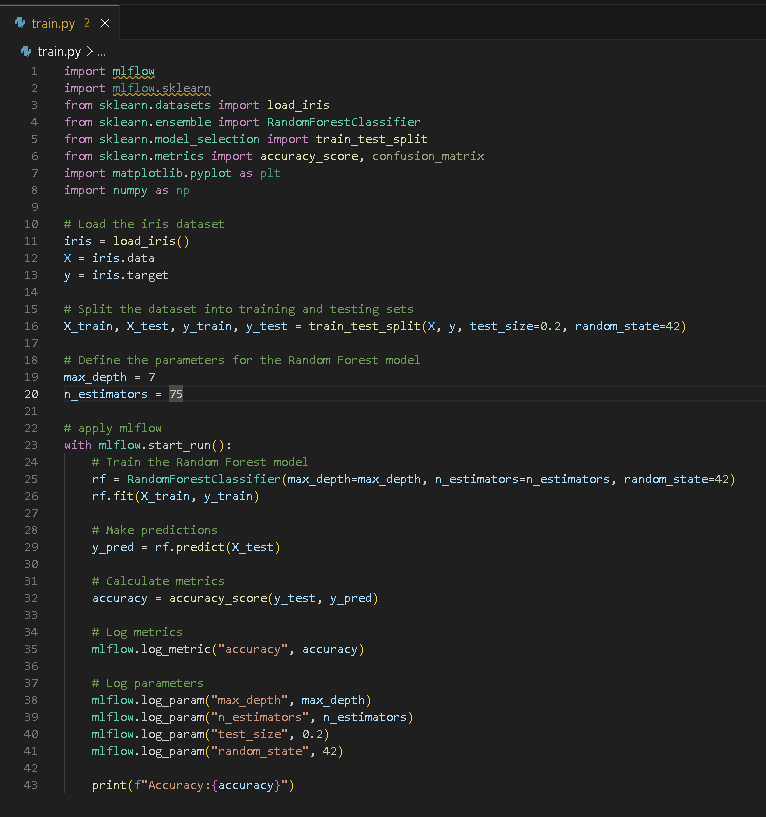


- To add experiment name: `with mlflow.start_run(run_name='dt_exp'):`
- **what can mlflow track**

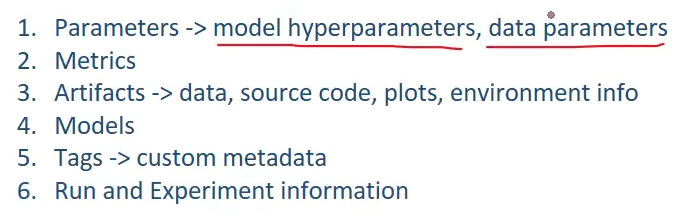

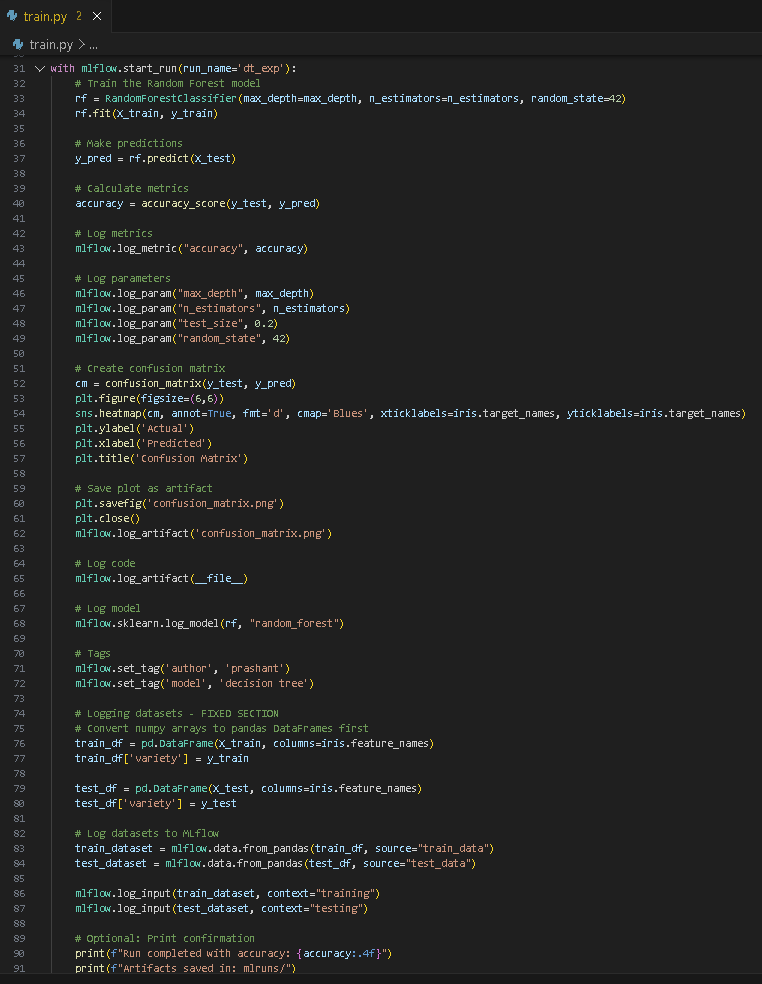

#### MLFlow remote tracking server

1. dagshub
2. aws

#### MLFlow Hyper Parameter Tuning

##### without mlflow

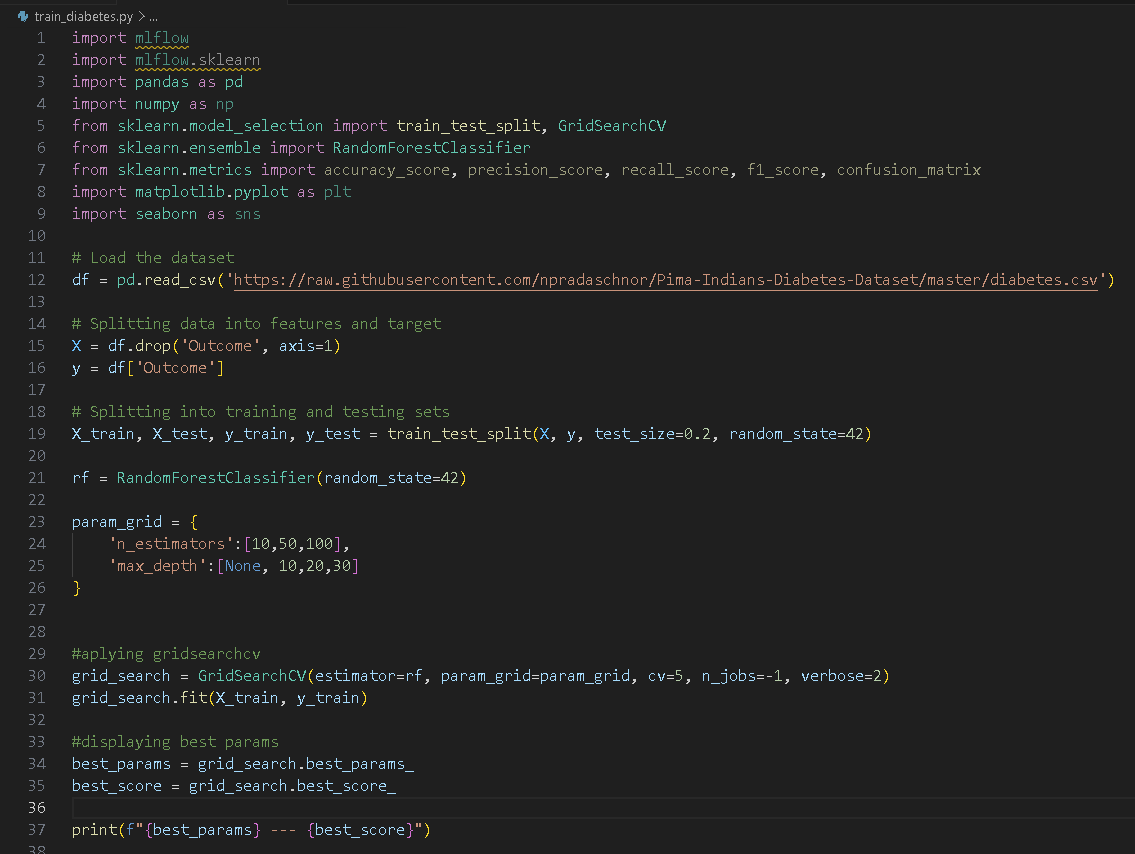

##### with mlflow

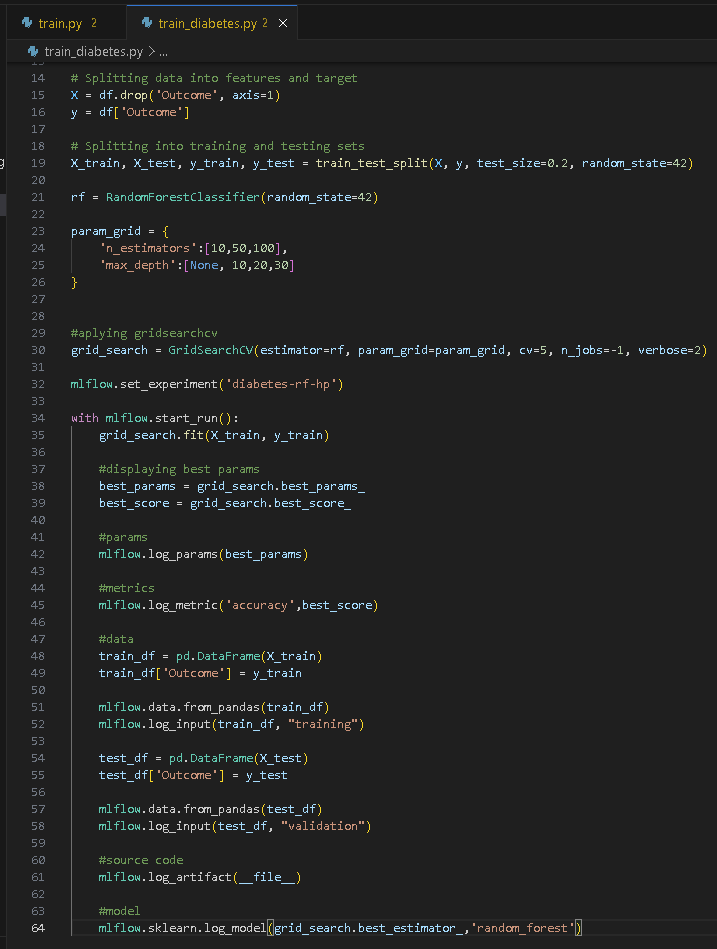

##### Currently, we only log the best parameters from GridSearchCV. However, to perform comprehensive hyperparameter analysis, we need to log every combination tested—not just the winning one.

- `Using Nested Runs`

- Compare performance across all parameter combinations
- Visualize trends (e.g., how accuracy changes with n_estimators)
- Identify overfitting by tracking validation scores
- Understand parameter sensitivity for future tuning
- Reproduce any experiment, not just the best one


- **When we performed hyper parameter tuning, we can easily compare how accuracy changes which gives us more insights:**

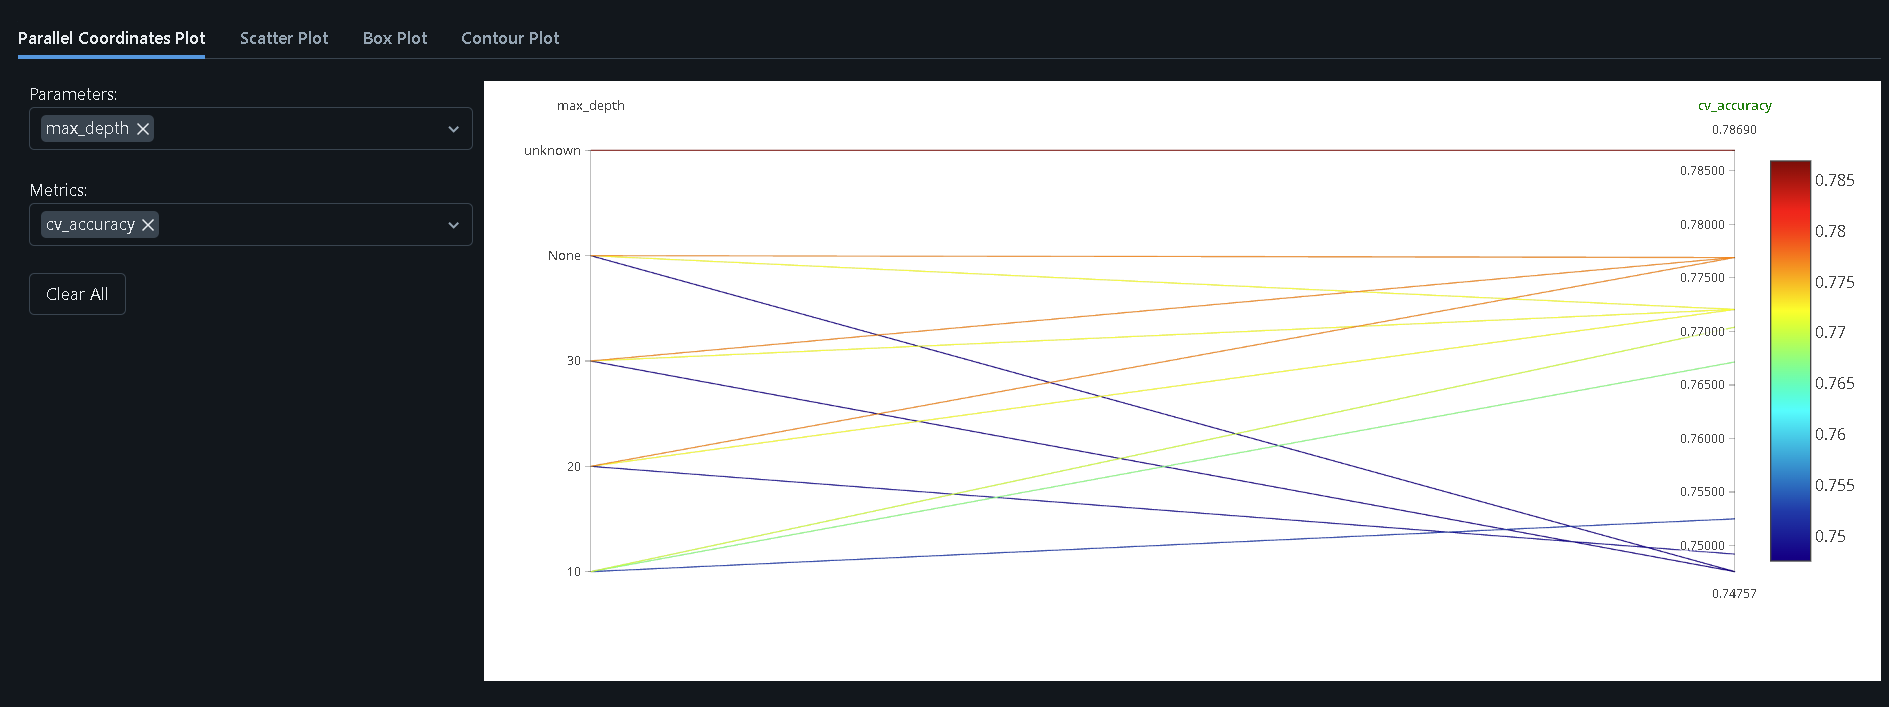

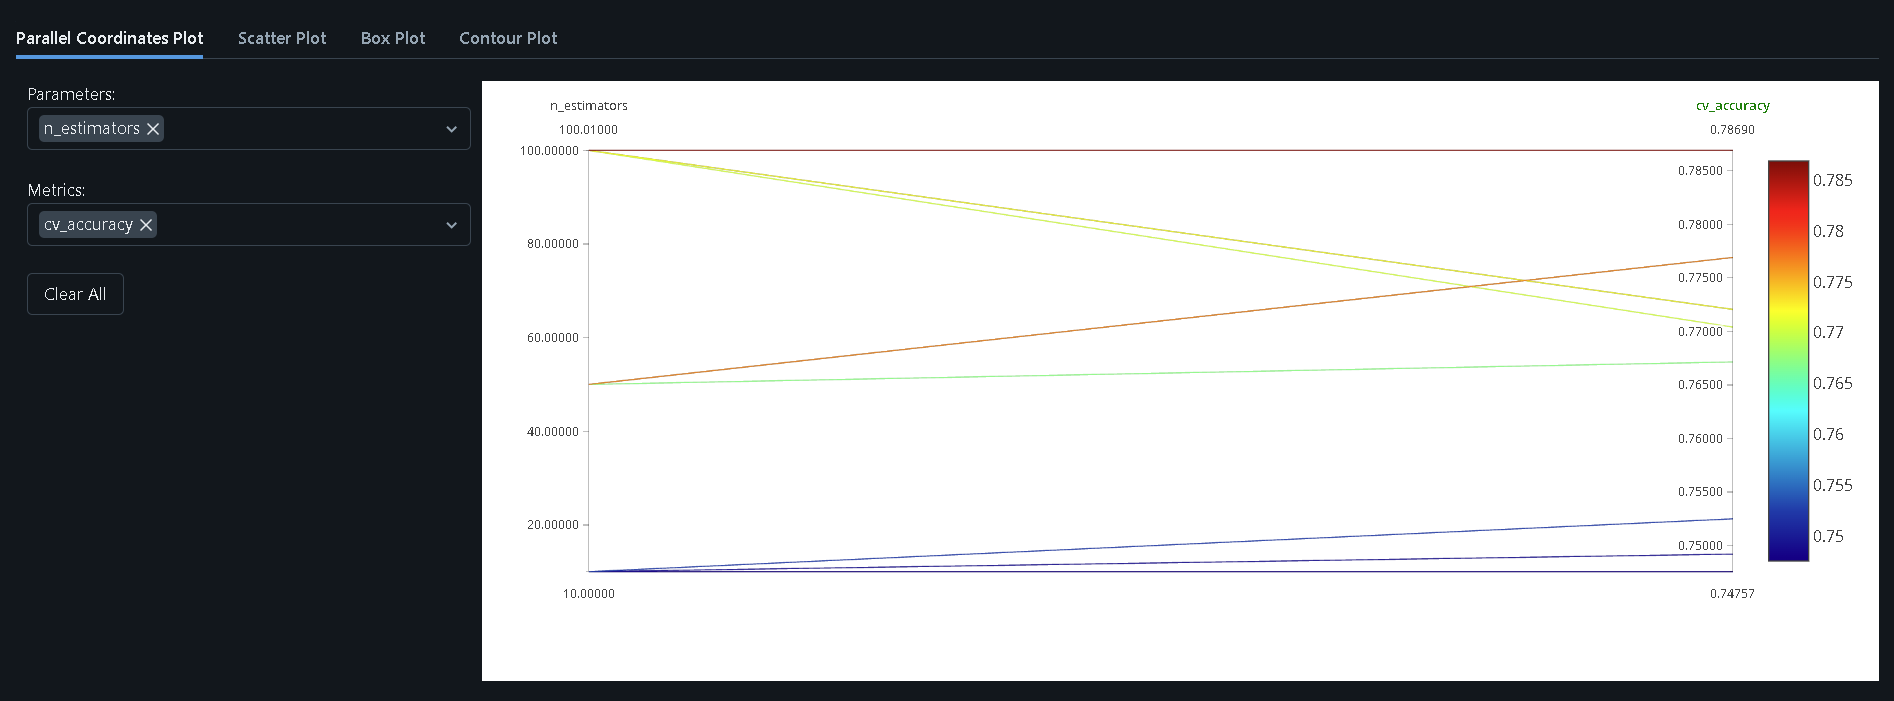

#### Model Registry

- Its a centralized repo to manage/store ml models and from there, Its deployed
- This is a midpoint where data scientist & mlops collaberate
- data scientists will run experiments, find best model and push best model to model registry
- mlops engineer will pick best model and deploy on live server


- **WorkFlow**
    1. Data scientists will run multiple experiments on the problem to find optimal solution
    2. Analyse the models params accuracy, precision, recall etc
    3. Select Best Model
    4. Push to Model Registry
    5. ML Ops engineer will pick the best model and deploy


- **Features of Model Registry**
    - model storage
    - model versioning
    - model meta data mgmt
    - model lineage (which experiment any model coming from)
    - collabration 
    - access control & security
    - deployment (directly fetch and deploy in cicd pipeline)
    - lifecycle mgmt (when we archive the model but still keep the detailed information to restore)



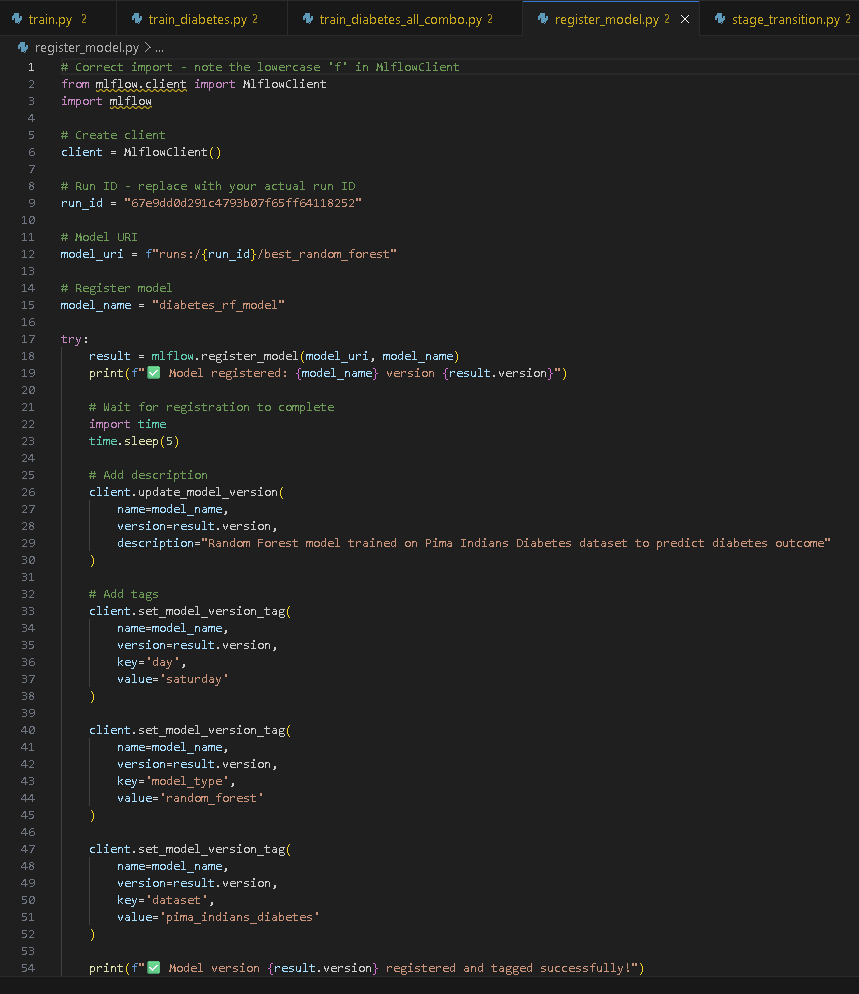

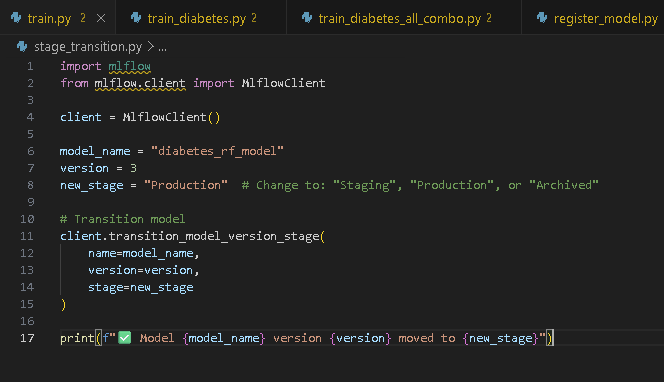


- `Once model is in production, we build a Flask/Fast api which fetches model in production and do predictions based on new input data`

### Test Project: Frieght Price Prediction

1. Project Folder (git init, dvc init)
2. Create github repo
3. git remote add origin <github url>
4. Problem & Solution
5. Gather Data (webscrape or from dbs)
6. Go through data (understand)
7. Data Assesing, Cleaning, Transformation
8. EDA
9. Repeat and prepare final dataset
10. Perform Experiments to find best features, algorithms, parameters
11. Create DVC pipeline
    - dvc remote add -d myremote C:\Users\iampr\AppData\Local\Temp\frieght_data -----> **add s3 path for ci/cd setup**
    - src (ingestion, preprocessing, feature engineering, model building, evaluation etc)
12. Create FastAPI or FlaskApi or Streamlit
13. 